# Sensor Placement Optimisation (MuJoCo)

Optimises the **sensor type** assigned to **5 fixed vehicle mount slots** using CMA-ES.

```
Slots: top_front_edge_l  |  top_front_edge_r  |  front_face_center
       side_front_edge_l  |  side_front_edge_r
```

**Run order (read before starting)**
1. Run **Cell 1** (CMA ABI fix) → `Runtime → Restart session`.
2. Run **Cells 2 – 4** (clone, install, verify imports).
3. Edit **Cell 5** (user config) to taste.
4. Run **Cells 6 – 9** (patches) — these rewrite cloned source files; run once per session.
5. Run **Cell 10** (experiment).
6. Run **Cells 11 – 12** (visualisations) after the run completes.

> **Tip — quick smoke test:** set `MAX_GENERATIONS = 5` and `N_EPISODES = 3` in Cell 5 before your first run.

In [ ]:
# ── Cell 1 ─ CMA / NumPy ABI fix ────────────────────────────────────────────
# Run this cell ONCE, then do Runtime → Restart session before continuing.
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--force-reinstall", "--no-cache-dir", "cma",
])
print("✅ cma reinstalled — do Runtime → Restart session NOW, then run Cell 2 onwards.")

✅ cma reinstalled — do Runtime → Restart session NOW, then run Cell 2 onwards.


In [ ]:
# ── Cell 2 ─ Clone repo + install requirements ───────────────────────────────
import os, shutil, subprocess, sys
from pathlib import Path

WORK   = Path("/content")
TARGET = Path("/content/sensor_placement_opt_MUJOCO_ver")

if not (TARGET / "sensor_opt").is_dir():
    if TARGET.exists():
        shutil.rmtree(TARGET, ignore_errors=True)
    os.chdir(WORK)
    subprocess.check_call([
        "git", "clone", "--depth", "1",
        "https://github.com/dcaglar-28/sensor_placement_opt_MUJOCO_ver.git",
        str(TARGET.name),
    ])

os.chdir(TARGET)
if str(TARGET) not in sys.path:
    sys.path.insert(0, str(TARGET))

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
print("cwd:", os.getcwd())

cwd: /content/sensor_placement_opt_MUJOCO_ver


In [ ]:
# ── Cell 3 ─ Verify import stack ─────────────────────────────────────────────
import os, sys
from pathlib import Path

TARGET = Path("/content/sensor_placement_opt_MUJOCO_ver")
os.chdir(TARGET)
if str(TARGET) not in sys.path:
    sys.path.insert(0, str(TARGET))

import cma, jax, matplotlib, mlflow, mujoco
import numpy as np, pandas as pd, rich, scipy, sklearn, torch, yaml
import sensor_opt

print("✅ All imports OK — MuJoCo", mujoco.__version__)

✅ All imports OK — MuJoCo 3.8.0


In [ ]:
# ── Cell 4 ─ USER CONFIGURATION (edit this cell only) ────────────────────────
#
# OPTIMIZATION_MODE selects the loss preset for this run.
#   "safety_first" — minimise blind-spots + collisions; bandwidth cost is a tiebreaker
#   "efficiency"   — still safety-heavy, but strongly penalises high-bandwidth sensors
#
OPTIMIZATION_MODE = "efficiency"   # ← swap to "efficiency" for second run

# ── Scenario ──────────────────────────────────────────────────────────────────
TRIAL_TYPE        = "multi_objective"
PATH_LENGTH_M     = 15.0
VEHICLE_SPEED_MPS = 5.0
BASE_RANDOM_SEED  = 42
MAX_GENERATIONS   = 200    # 5–25 smoke-test; 50–100 for real results
N_EPISODES        = 3
CMA_POPSIZE       = 20

# ── Hardware platform ─────────────────────────────────────────────────────────
# Enter your chip + memory specs here. Bandwidth is the key constraint on
# unified-memory chips (M-series, Snapdragon X, etc.) because CPU, GPU, and
# Neural Engine all share the same pool.
HARDWARE_PLATFORM = {
    "name":                  "Apple M5 (24 GB)",
    "total_memory_gb":       24,
    "memory_bandwidth_gbps": 153.6,   # LPDDR5X @ 9600 MT/s
    "neural_engine_tops":    38,      # used for latency scaling (future)
}


# "jetson_orin": {
#         "name":                  "NVIDIA Jetson Orin (32 GB)",
#         "total_memory_gb":       32,
#         "memory_bandwidth_gbps": 204.8,   # LPDDR5 @ 6400 MT/s ×2 channels
#         "neural_engine_tops":    275,     # NVDLA + GPU tensor cores
#     }

# ── Sensor specs — enter values from your datasheets ─────────────────────────
# data_rate_mbps : raw data the sensor streams per active instance
# fov_deg        : horizontal field-of-view
# max_range_m    : detection range
# latency_s      : processing latency (sensor → usable output)
# n_rays         : ray-cast density used in MuJoCo simulation
# max_count      : how many physical units you actually have available
#
# These values flow automatically into:
#   • the MuJoCo yaml patch (Cell 7) — so DO NOT edit sensor params there
#   • the cost function         (bandwidth fraction replaces USD cost)
#   • the per-type availability cap

SENSOR_SPECS = {
    "lidar": {
        "data_rate_mbps":  250,   # 128-ch lidar ~250 Mbps
        "fov_deg":         120,
        "max_range_m":      20,
        "latency_s":       0.10,
        "n_rays":           64,
        "max_count":         2,   # units physically available
    },
    "radar": {
        "data_rate_mbps":    5,   # radar output is small
        "fov_deg":          90,
        "max_range_m":      20,
        "latency_s":        0.05,
        "n_rays":           32,
        "max_count":         3,
    },
    "camera": {
        "data_rate_mbps":   40,   # 1080p30 compressed
        "fov_deg":          60,
        "max_range_m":      10,
        "latency_s":        0.033,
        "n_rays":           16,
        "max_count":         5,
    },
    "disabled": {
        "data_rate_mbps":    0,
        "fov_deg":           0,
        "max_range_m":       0,
        "latency_s":         0.0,
        "n_rays":            0,
        "max_count":        99,
    },
}

# ── Derived values (computed automatically — do not edit below this line) ─────

# Cost = bandwidth fraction × 10 000 (integer-safe, dimensionless)
# This replaces the old USD cost. The optimizer penalises sensors that eat
# a larger share of the chip's memory bandwidth.
_bw_mbps = HARDWARE_PLATFORM["memory_bandwidth_gbps"] * 1_000
SENSOR_COSTS_USD = {          # name kept for back-compat with the run cell
    k: int((v["data_rate_mbps"] / _bw_mbps) * 10_000)
    for k, v in SENSOR_SPECS.items()
}

# Per-type availability caps fed directly from SENSOR_SPECS
MAX_SENSOR_COUNTS = {k: v["max_count"] for k, v in SENSOR_SPECS.items()}
MAX_SENSOR_COUNT  = None   # legacy single-cap; superseded by MAX_SENSOR_COUNTS

# Total budget cap expressed in the same bandwidth-fraction units
# (10 000 = 100% of bandwidth; 5 simultaneous sensors shouldn't exceed ~50%)
# Budget cap expressed in bandwidth-fraction cost units (same scale as SENSOR_COSTS_USD).
# MAX_BANDWIDTH_FRACTION = fraction of total chip bandwidth sensors may consume.
# 0.30 → sensors collectively may use at most 30% of the M5's 153.6 GB/s.
# Raise this if you want the optimizer to consider more/heavier sensors.
MAX_BANDWIDTH_FRACTION  = 0.30
MAX_HARDWARE_BUDGET_USD = int(MAX_BANDWIDTH_FRACTION * 10_000)  # e.g. 0.30 → 3000 cost units

# ── Loss weight presets ───────────────────────────────────────────────────────
_LOSS_PRESETS = {
    # Preset 1 — Safety first
    # Blind-spot coverage and detection latency dominate; bandwidth cost is
    # only a tiebreaker between otherwise equivalent configs.
    "safety_first": {
        "w_acc":  0.60,   # detection rate  ← primary
        "w_lat":  0.35,   # latency         ← secondary
        "w_cost": 0.05,   # bandwidth cost  ← tiebreaker
    },
    # Preset 2 — Efficiency
    # Still safety-heavy, but now 30% of the loss comes from bandwidth cost.
    # Will push the optimizer toward cameras + radar over lidar.
    "efficiency": {
        "w_acc":  0.45,
        "w_lat":  0.25,
        "w_cost": 0.30,   # strong bandwidth pressure
    },
}

assert OPTIMIZATION_MODE in _LOSS_PRESETS, (
    f"Unknown OPTIMIZATION_MODE '{OPTIMIZATION_MODE}'. "
    f"Choose from: {list(_LOSS_PRESETS)}"
)
LOSS_WEIGHT_OVERRIDES = _LOSS_PRESETS[OPTIMIZATION_MODE]

# ── Derived scenario scaling (computed automatically — do not edit) ───────────
# Obstacle density stays at 1 per metre regardless of path length
N_OBSTACLES = int(PATH_LENGTH_M * 1.0)

# Lateral scatter widens with speed so side sensors stay genuinely relevant.
# Baseline: ±1.5 m at 5 m/s. Capped at ±3.0 m.
_LATERAL_M = round(min(1.5 * (VEHICLE_SPEED_MPS / 5.0), 3.0), 2)

# ── Summary ───────────────────────────────────────────────────────────────────
_bw_pct = {k: f"{v/100:.2f}%" for k, v in SENSOR_COSTS_USD.items()}
print(f"Platform       : {HARDWARE_PLATFORM['name']}")
print(f"Bandwidth      : {HARDWARE_PLATFORM['memory_bandwidth_gbps']} GB/s  |  Memory: {HARDWARE_PLATFORM['total_memory_gb']} GB")
print(f"Optimization   : {OPTIMIZATION_MODE.upper()}")
print(f"Loss weights   : {LOSS_WEIGHT_OVERRIDES}")
print(f"Bandwidth cost : {_bw_pct}  (fraction of {HARDWARE_PLATFORM['memory_bandwidth_gbps']} GB/s)")
print(f"Sensor caps    : { {k: v['max_count'] for k,v in SENSOR_SPECS.items() if k != 'disabled'} }")
print(f"Generations    : {MAX_GENERATIONS}  |  Episodes/eval: {N_EPISODES}")
print("Ready — run patch cells (5–8) before starting the experiment.")


Platform       : Apple M5 (24 GB)
Bandwidth      : 153.6 GB/s  |  Memory: 24 GB
Optimization   : EFFICIENCY
Loss weights   : {'w_acc': 0.45, 'w_lat': 0.25, 'w_cost': 0.3}
Bandwidth cost : {'lidar': '0.16%', 'radar': '0.00%', 'camera': '0.02%', 'disabled': '0.00%'}  (fraction of 153.6 GB/s)
Sensor caps    : {'lidar': 2, 'radar': 3, 'camera': 5}
Generations    : 200  |  Episodes/eval: 3
Ready — run patch cells (5–8) before starting the experiment.


In [ ]:
# ── Cell 5 ─ Patch obstacles.py ──────────────────────────────────────────────
# lateral_m and N_OBSTACLES are derived from Cell 4 (PATH_LENGTH_M, VEHICLE_SPEED_MPS).
# Must always run AFTER Cell 4.
from pathlib import Path

dest = Path('/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/obstacles.py')

_TEMPLATE = '''\
"""Obstacle layouts for the MuJoCo sensor-placement simulation."""
from __future__ import annotations
from typing import List, Tuple
import numpy as np

Position = Tuple[float, float, float]

FIXED_SEEDS: List[int] = [42_000, 43_000, 44_000]


def generate_obstacles(
    n_obstacles: int,
    path_length_m: float,
    rng_seed: int,
    lateral_m: float = LAT_PLACEHOLDER,
) -> List[Position]:
    """Return (x, y, z) obstacle positions."""
    n = int(max(0, n_obstacles))
    lo_x = 2.0
    hi_x = max(lo_x, float(path_length_m) - 1.0)
    rng = np.random.default_rng(int(rng_seed))
    return [
        (float(rng.uniform(lo_x, hi_x)), float(rng.uniform(-lateral_m, lateral_m)), 0.15)
        for _ in range(n)
    ]


def get_fixed_seeds() -> List[int]:
    """Convenience accessor for the canonical seed list."""
    return list(FIXED_SEEDS)


def get_generation_seed(generation_index: int) -> int:
    """Return a deterministic seed for a given generation index (wraps over FIXED_SEEDS)."""
    return FIXED_SEEDS[generation_index % len(FIXED_SEEDS)]
'''
src = _TEMPLATE.replace('LAT_PLACEHOLDER', str(_LATERAL_M))
dest.write_text(src, encoding='utf-8')

print(f'✅ obstacles.py patched — ±{_LATERAL_M} m lateral | {N_OBSTACLES} obstacles | 3 fixed seeds')
for line in dest.read_text().split('\n'):
    if 'lateral_m' in line:
        print(f'   {line}')


✅ obstacles.py patched — ±1.5 m lateral | 15 obstacles | 3 fixed seeds
       lateral_m: float = 1.5,
           (float(rng.uniform(lo_x, hi_x)), float(rng.uniform(-lateral_m, lateral_m)), 0.15)


In [ ]:
# ── Cell 6 ─ Patch mjcf.py ───────────────────────────────────────────────────
# Shrink obstacle sphere radius 0.25 → 0.15 m so that:
#   • spheres sit on the ground at z=0.15 (centre height == radius)
#   • smaller targets make sensor type / FOV differences more meaningful
from pathlib import Path

mjcf_path = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/mjcf.py")
src = mjcf_path.read_text(encoding="utf-8")

if 'size="0.15"' in src:
    print("ℹ️  mjcf.py already patched — skipping.")
elif 'size="0.25"' in src:
    src = src.replace('size="0.25"', 'size="0.15"')
    mjcf_path.write_text(src, encoding="utf-8")
    print("✅ mjcf.py patched — obstacle radius 0.25 → 0.15 m")
else:
    print("⚠️  Expected size=\"0.25\" not found in mjcf.py — inspect manually.")
    !grep -n 'size=' {mjcf_path} | head -20

✅ mjcf.py patched — obstacle radius 0.25 → 0.15 m


In [ ]:
# ── Cell 7 ─ Patch mujoco_vehicle.yaml ───────────────────────────────────────
# Sensor params (fov, range, latency, n_rays) are now pulled from SENSOR_SPECS
# defined in Cell 4. Do NOT edit sensor values here directly.
import yaml
from pathlib import Path

cfg_path = Path("/content/sensor_placement_opt_MUJOCO_ver/configs/mujoco_vehicle.yaml")
cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))

# Build sensor_overrides from SENSOR_SPECS (set in Cell 4)
sensor_overrides = {
    k: {
        "n_rays":      v["n_rays"],
        "fov_deg":     v["fov_deg"],
        "max_range_m": v["max_range_m"],
        "latency_s":   v["latency_s"],
    }
    for k, v in SENSOR_SPECS.items()
    if k != "disabled"
}

for sensor, params in sensor_overrides.items():
    cfg.setdefault("sensor_models", {}).setdefault(sensor, {}).update(params)

cfg_path.write_text(yaml.dump(cfg, default_flow_style=False, sort_keys=False), encoding="utf-8")
print(f"✅ mujoco_vehicle.yaml patched from SENSOR_SPECS ({HARDWARE_PLATFORM['name']})")
print("   Sensor models applied:")
for s, p in sensor_overrides.items():
    print(f"     {s:8s}  fov={p['fov_deg']:>4}°  range={p['max_range_m']:>4}m  "
          f"latency={p['latency_s']:.3f}s  rays={p['n_rays']}")
!grep -A6 'sensor_models:' {cfg_path}


✅ mujoco_vehicle.yaml patched from SENSOR_SPECS (Apple M5 (24 GB))
   Sensor models applied:
     lidar     fov= 120°  range=  20m  latency=0.100s  rays=64
     radar     fov=  90°  range=  20m  latency=0.050s  rays=32
     camera    fov=  60°  range=  10m  latency=0.033s  rays=16
sensor_models:
  lidar:
    cost_usd: 2000
    range_m: 25
    horizontal_fov_deg: 120
    vertical_fov_deg: 120
    latency_ms: 100


In [ ]:
# ── Cell 8 ─ Patch mujoco_env_manager.py ─────────────────────────────────────
# Cycles episodes through the same 3 fixed seeds defined in obstacles.py,
# replacing the original per-generation variable seed.
#
# Fixes vs original:
#   • _FIXED_SEEDS list matches obstacles.py exactly (3 seeds, not 6)
#   • safe replace: checks for already-patched state before asserting
from pathlib import Path

env_path = Path(
    "/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py"
)
src = env_path.read_text(encoding="utf-8")

_OLD = """            pos = generate_obstacles(
                self.n_obstacles,
                self.path_length_m,
                gen_seed + ep,
            )"""

# Must match FIXED_SEEDS in obstacles.py (3 entries).
_NEW = """            # Cycle through 3 fixed obstacle layouts for deterministic evaluation.
            # Seed list must stay in sync with FIXED_SEEDS in simulation/obstacles.py.
            _FIXED_SEEDS = [42_000, 43_000, 44_000]
            ep_seed = _FIXED_SEEDS[ep % len(_FIXED_SEEDS)]
            pos = generate_obstacles(
                self.n_obstacles,
                self.path_length_m,
                ep_seed,
            )"""

_SENTINEL = "_FIXED_SEEDS = [42_000, 43_000, 44_000]"

if _SENTINEL in src:
    print("ℹ️  mujoco_env_manager.py already patched — skipping.")
elif _OLD in src:
    src = src.replace(_OLD, _NEW)
    env_path.write_text(src, encoding="utf-8")
    print("✅ mujoco_env_manager.py patched — 3-seed episode cycling.")
else:
    print("⚠️  Target pattern not found — the upstream file may have changed.")
    print("    Inspect the file and update _OLD to match:")
    !grep -n 'gen_seed\|generate_obstacles' {env_path} | head -20

print("Verifying:")
!grep -A5 '_FIXED_SEEDS' {env_path} | head -15

✅ mujoco_env_manager.py patched — 3-seed episode cycling.
Verifying:
            _FIXED_SEEDS = [42_000, 43_000, 44_000]
            ep_seed = _FIXED_SEEDS[ep % len(_FIXED_SEEDS)]
            pos = generate_obstacles(
                self.n_obstacles,
                self.path_length_m,
                ep_seed,
            )


In [ ]:
# ── Fix: remove get_generation_seed from mujoco_env_manager.py ───────────────
from pathlib import Path

path = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py")
src = path.read_text(encoding="utf-8")
print("BEFORE (import line):")
for line in src.splitlines():
    if "get_generation_seed" in line:
        print(" ", line)

# Fix the import line
fixed = src.replace(
    "from sensor_opt.simulation.obstacles import generate_obstacles, get_generation_seed",
    "from sensor_opt.simulation.obstacles import generate_obstacles",
).replace(
    "from sensor_opt.simulation.obstacles import get_generation_seed, generate_obstacles",
    "from sensor_opt.simulation.obstacles import generate_obstacles",
)

# Fix any call sites — replace get_generation_seed(...) with the rng seed directly
# The patched obstacles.py cycles seeds via _FIXED_SEEDS in env_manager itself,
# so any call like get_generation_seed(gen) should become the inline equivalent.
# Most common pattern: seed = get_generation_seed(generation) → remove or inline.
import re
fixed = re.sub(r'\bget_generation_seed\b', '_get_generation_seed_REMOVED', fixed)

path.write_text(fixed, encoding="utf-8")
print("\nAFTER — remaining references:")
remaining = [l for l in fixed.splitlines() if "get_generation_seed" in l]
print("\n".join(remaining) if remaining else "  None ✅")
print("\n✅ Done — but check remaining references above before running Cell 9.")

BEFORE (import line):
  from sensor_opt.simulation.obstacles import generate_obstacles, get_generation_seed
          gen_seed = get_generation_seed(self._gen, self.base_random_seed)

AFTER — remaining references:
        gen_seed = _get_generation_seed_REMOVED(self._gen, self.base_random_seed)

✅ Done — but check remaining references above before running Cell 9.


In [ ]:
# ── Audit: find ALL remaining get_generation_seed references ─────────────────
import subprocess
result = subprocess.run(
    ["grep", "-rn", "get_generation_seed",
     "/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/"],
    capture_output=True, text=True
)
print(result.stdout or "✅ No references remain — safe to run Cell 9.")

/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/__init__.py:3:from sensor_opt.simulation.obstacles import generate_obstacles, get_generation_seed
/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/__init__.py:9:    "get_generation_seed",
/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/obstacles.py:33:def get_generation_seed(generation_index: int) -> int:
/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py:127:        gen_seed = _get_generation_seed_REMOVED(self._gen, self.base_random_seed)



In [ ]:
# ── Inspect the call site ─────────────────────────────────────────────────────
from pathlib import Path

src = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py").read_text()
lines = src.splitlines()
for i, line in enumerate(lines):
    if "_get_generation_seed_REMOVED" in line or "_FIXED_SEEDS" in line or "gen_seed" in line:
        start = max(0, i - 3)
        end = min(len(lines), i + 5)
        print(f"── line {i+1} ──")
        print("\n".join(f"{j+1}: {lines[j]}" for j in range(start, end)))
        print()

── line 127 ──
124:         scfg = _slot_to_config(config)
125:         sspec = get_sensor_specs(self._exp_cfg)
126:         n_ep = max(1, n_episodes)
127:         gen_seed = _get_generation_seed_REMOVED(self._gen, self.base_random_seed)
128:         sim_c = {
129:             "path_length_m": self.path_length_m,
130:             "vehicle_speed_mps": self.vehicle_speed_mps,
131:             "timestep_s": self.timestep_s,

── line 144 ──
141:         for ep in range(n_ep):
142:             # Cycle through 3 fixed obstacle layouts for deterministic evaluation.
143:             # Seed list must stay in sync with FIXED_SEEDS in simulation/obstacles.py.
144:             _FIXED_SEEDS = [42_000, 43_000, 44_000]
145:             ep_seed = _FIXED_SEEDS[ep % len(_FIXED_SEEDS)]
146:             pos = generate_obstacles(
147:                 self.n_obstacles,
148:                 self.path_length_m,

── line 145 ──
142:             # Cycle through 3 fixed obstacle layouts for deterministic evaluat

In [ ]:
# ── Fix both files ────────────────────────────────────────────────────────────
import re
from pathlib import Path

# 1. __init__.py — remove from __all__ / export list
init_path = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/__init__.py")
src = init_path.read_text(encoding="utf-8")
fixed = re.sub(r',?\s*["\']get_generation_seed["\']', "", src)
fixed = re.sub(r'["\']get_generation_seed["\'],?\s*', "", fixed)
init_path.write_text(fixed, encoding="utf-8")
print("✅ __init__.py cleaned")

# 2. mujoco_env_manager.py — replace the removed call with inline seed logic.
#    The original get_generation_seed(gen, base_seed) almost certainly just did:
#      base_seed + gen   (or a simple deterministic combination)
#    Cell 8's patch uses _FIXED_SEEDS cycling, so we replace the call with that.
mgr_path = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py")
src = mgr_path.read_text(encoding="utf-8")

# Replace the broken call with inline seed derived from _FIXED_SEEDS cycling
fixed = src.replace(
    "gen_seed = _get_generation_seed_REMOVED(self._gen, self.base_random_seed)",
    "gen_seed = _FIXED_SEEDS[self._gen % len(_FIXED_SEEDS)]",
)

mgr_path.write_text(fixed, encoding="utf-8")
print("✅ mujoco_env_manager.py call site fixed")

# 3. Final audit
import subprocess
result = subprocess.run(
    ["grep", "-rn", "get_generation_seed",
     "/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/"],
    capture_output=True, text=True
)
print("\nRemaining references:")
print(result.stdout or "  None ✅ — safe to run Cell 9.")

✅ __init__.py cleaned
✅ mujoco_env_manager.py call site fixed

Remaining references:
/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/__init__.py:3:from sensor_opt.simulation.obstacles import generate_obstacles, get_generation_seed
/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/simulation/obstacles.py:33:def get_generation_seed(generation_index: int) -> int:



In [ ]:
# ── Complete rewrite of mujoco_env_manager.py with CRN ───────────────────────
from pathlib import Path

NEW_SRC = '''"""
MuJoCo: kinematic vehicle on +X, five fixed sites, mocap obstacle pool.
Contacts vehicle–obstacles are excluded in MJCF. Geometry via mj_kinematics (no mj_step in episode).

Seed strategy — Common Random Numbers (CRN):
  - Each generation draws a fresh pool of N_CRN_SEEDS seeds derived from
    (base_random_seed, generation). Every candidate in that generation is
    evaluated on the SAME pool, making within-generation loss comparisons
    fair (apples-to-apples). Across generations the pool rotates, so the
    optimizer cannot overfit to a fixed set of obstacle layouts.
"""

from __future__ import annotations

from typing import Any, Dict, List

import numpy as np

from sensor_opt.encoding.config import SensorConfig
from sensor_opt.loss.loss import EvalMetrics
from sensor_opt.simulation.mjcf import SLOT_NAMES, build_vehicle_mjcf
from sensor_opt.simulation.mujoco_runner import run_episode
from sensor_opt.simulation.obstacles import generate_obstacles
from sensor_opt.simulation.sensor_specs import get_sensor_specs

try:
    import mujoco
except ImportError:  # pragma: no cover
    mujoco = None  # type: ignore[assignment]

# Number of distinct obstacle layouts sampled per generation.
# 10 is enough to reduce layout variance while keeping evaluation fast.
# Increase to 20-50 for final/publication runs.
N_CRN_SEEDS = 10


def _crn_seeds(base_seed: int, generation: int, n: int) -> list[int]:
    """Return n deterministic seeds for this generation using CRN.

    Seeds are derived from (base_seed, generation) so they are:
      - identical for all candidates within a generation (fair comparison)
      - different across generations (no cross-generation overfitting)
    """
    rng = np.random.default_rng([int(base_seed), int(generation)])
    return [int(s) for s in rng.integers(0, 2**31 - 1, size=n)]


def _slot_to_config(config: SensorConfig) -> Dict[str, str]:
    out: Dict[str, str] = {s: "disabled" for s in SLOT_NAMES}
    for s in config.sensors:
        if s.slot in out:
            out[str(s.slot)] = str(s.sensor_type) if s.is_active() else "disabled"
    return out


class MujocoEnvManager:
    def __init__(
        self,
        *,
        num_envs: int = 1,
        n_obstacles: int = 10,
        path_length_m: float = 20.0,
        vehicle_speed_mps: float = 2.0,
        timestep_s: float = 0.02,
        base_random_seed: int = 42,
        max_steps_per_episode: int = 2000,
        _sensor_noise_std: float = 0.0,
        **_: Any,
    ) -> None:
        if mujoco is None:  # pragma: no cover
            raise ImportError("MuJoCo is not installed. Install with: pip install mujoco>=3.1")
        self.num_envs = int(max(1, num_envs))
        self.n_obstacles = int(max(1, n_obstacles))
        self.path_length_m = float(path_length_m)
        self.vehicle_speed_mps = float(vehicle_speed_mps)
        self.timestep_s = float(timestep_s)
        self.base_random_seed = int(base_random_seed)
        self.max_steps_per_episode = int(max_steps_per_episode)
        self._sn = float(_sensor_noise_std or 0.0)
        self._slots: list[tuple[SensorConfig | None, dict | None]] = [
            (None, None) for _ in range(self.num_envs)
        ]
        self._gen: int = 0
        self._crn_seeds: list[int] = _crn_seeds(self.base_random_seed, 0, N_CRN_SEEDS)
        xml = build_vehicle_mjcf(self.n_obstacles)
        self.model = mujoco.MjModel.from_xml_string(xml)
        self.data = mujoco.MjData(self.model)
        self._exp_cfg: dict = {}

    def set_experiment_config(self, cfg: dict) -> None:
        self._exp_cfg = dict(cfg or {})
        il = self._exp_cfg.get("inner_loop", {})
        mj: Dict[str, Any] = (il or {}).get("mujoco", {}) or {} if isinstance(il, dict) else {}
        if isinstance(mj, dict) and mj:
            self.n_obstacles = int(mj.get("n_obstacles", self.n_obstacles))
            self.path_length_m = float(mj.get("path_length_m", self.path_length_m))
            self.vehicle_speed_mps = float(mj.get("vehicle_speed_mps", self.vehicle_speed_mps))
            self.timestep_s = float(mj.get("timestep_s", self.timestep_s))
            if mj.get("base_random_seed") is not None:
                self.base_random_seed = int(mj.get("base_random_seed", 42))
        rt = self._exp_cfg.get("runtime", {})
        if not isinstance(rt, dict):
            rt = {}
        if rt.get("base_random_seed") is not None:
            self.base_random_seed = int(rt["base_random_seed"])
        if rt.get("n_obstacles") is not None:
            self.n_obstacles = int(rt["n_obstacles"])
        if rt.get("path_length_m") is not None:
            self.path_length_m = float(rt["path_length_m"])
        if rt.get("vehicle_speed_mps") is not None:
            self.vehicle_speed_mps = float(rt["vehicle_speed_mps"])
        if rt.get("timestep_s") is not None:
            self.timestep_s = float(rt["timestep_s"])

    def reconfigure_sensors(self, env_idx: int, config: SensorConfig, sensor_models: dict) -> None:
        if env_idx < 0 or env_idx >= self.num_envs:
            raise IndexError("env_idx out of range")
        self._slots[env_idx] = (config, dict(sensor_models))

    def run_rollouts(
        self,
        n_episodes: int,
        rng: np.random.Generator,
        sensor_noise_std: float = 0.0,
        generation: int = 0,
    ) -> list[EvalMetrics]:
        _ = (rng, sensor_noise_std)
        gen = int(generation)
        # Refresh CRN seed pool when generation advances.
        # All candidates in the same generation share this pool.
        if gen != self._gen:
            self._gen = gen
            self._crn_seeds = _crn_seeds(self.base_random_seed, gen, N_CRN_SEEDS)

        out: list[EvalMetrics] = []
        for i in range(self.num_envs):
            cfg, sm = self._slots[i]
            if cfg is None or sm is None:
                out.append(_zero_metrics(n_episodes, self.n_obstacles))
                continue
            if not cfg.active_sensors():
                out.append(_zero_metrics(n_episodes, self.n_obstacles))
                continue
            out.append(self._rollout_one(cfg, sm, n_episodes))
        return out

    def _rollout_one(self, config: SensorConfig, sensor_models: dict, n_episodes: int) -> EvalMetrics:
        scfg = _slot_to_config(config)
        sspec = get_sensor_specs(self._exp_cfg)
        n_ep = max(1, n_episodes)

        # CRN: cycle through this generation\'s seed pool.
        # Each episode gets a unique, generation-specific seed.
        ep_seeds = [self._crn_seeds[i % N_CRN_SEEDS] for i in range(n_ep)]

        sim_c = {
            "path_length_m": self.path_length_m,
            "vehicle_speed_mps": self.vehicle_speed_mps,
            "timestep_s": self.timestep_s,
            "n_obstacles": self.n_obstacles,
        }
        covs: list[float] = []
        ndets: list[float] = []
        mdd: list[float] = []
        ftm: list[float] = []
        pslots: list[dict] = []
        n_obs_l: list[int] = []
        t_ep: list[float] = []

        for ep, ep_seed in enumerate(ep_seeds):
            pos = generate_obstacles(
                self.n_obstacles,
                self.path_length_m,
                ep_seed,
            )
            m = run_episode(
                self.model,
                self.data,
                scfg,
                pos,
                sim_c,
                sspec,
                np.random.default_rng(int(ep_seed) + 17 * ep),
            )
            covs.append(float(m["coverage_fraction"]))
            ndets.append(float(m["n_detected"]))
            mdd.append(float(m["mean_detection_distance"]))
            ft = m["first_detection_times"]
            T = float(m["episode_duration_s"])
            t_ep.append(T)
            vals: list[float] = []
            for f in ft:
                if f is None:
                    vals.append(T)
                else:
                    vals.append(float(f))
            ftm.append(float(np.mean(vals)) if vals else T)
            pslots.append(dict(m.get("per_slot_first_hits", {})))
            n_obs_l.append(int(m.get("n_obstacles", self.n_obstacles)))

        pmean = {s: 0.0 for s in SLOT_NAMES}
        for p in pslots:
            for k, v in p.items():
                if k in pmean:
                    pmean[k] += float(v) / n_ep

        return EvalMetrics(
            collision_rate=0.0,
            blind_spot_fraction=0.0,
            mean_goal_success=float(np.mean(ndets) / max(float(self.n_obstacles), 1.0)),
            n_episodes=n_ep,
            t_det_s=float(np.mean(ftm)),
            t_det_s_p95=float(np.percentile(np.asarray(ftm, dtype=np.float64), 95.0)),
            episode_time_s=float(np.mean(t_ep)) if t_ep else 0.0,
            detection_miss_rate=1.0 - float(np.mean(ndets) / max(float(self.n_obstacles), 1.0)),
            coverage_fraction=float(np.mean(covs)),
            n_detected=float(np.mean(ndets)),
            n_obstacles=float(np.mean(n_obs_l)),
            mean_detection_distance_m=float(np.mean(mdd)) if mdd else 0.0,
            first_detection_time_mean=float(np.mean(ftm)),
            per_slot_first_hits={k: float(v) for k, v in pmean.items()},
        )


def _zero_metrics(n_episodes: int, n_obstacles: int) -> EvalMetrics:
    T = 1.0
    return EvalMetrics(
        collision_rate=0.0,
        blind_spot_fraction=1.0,
        mean_goal_success=0.0,
        n_episodes=max(0, n_episodes),
        episode_time_s=T,
        coverage_fraction=0.0,
        n_detected=0.0,
        n_obstacles=float(n_obstacles),
        mean_detection_distance_m=0.0,
        first_detection_time_mean=T,
        per_slot_first_hits={s: 0.0 for s in SLOT_NAMES},
    )
'''

path = Path("/content/sensor_placement_opt_MUJOCO_ver/sensor_opt/inner_loop/mujoco_env_manager.py")
path.write_text(NEW_SRC, encoding="utf-8")
print(f"✅ Written {path.stat().st_size} bytes")
print("\nCRN seed pool preview (gen=0, base=42):")
import numpy as np
rng = np.random.default_rng([42, 0])
print(" ", [int(s) for s in rng.integers(0, 2**31 - 1, size=10)])
print("\nCRN seed pool preview (gen=1, base=42):")
rng = np.random.default_rng([42, 1])
print(" ", [int(s) for s in rng.integers(0, 2**31 - 1, size=10)])
print("\n✅ Pools are different across generations — CRN is working.")
print("Now run Cell 9.")

✅ Written 9685 bytes

CRN seed pool preview (gen=0, base=42):
  [191664963, 1662057957, 1405681631, 942484272, 929893137, 1843824992, 184566854, 1497586438, 432652533, 202244314]

CRN seed pool preview (gen=1, base=42):
  [1370068125, 1704034044, 965090078, 528192194, 1975775578, 868498938, 1766788444, 1358831403, 1938359164, 1752763708]

✅ Pools are different across generations — CRN is working.
Now run Cell 9.


In [ ]:
# ── Cell 9 ─ Build config and run optimisation ────────────────────────────────
import os, subprocess, sys, time
from pathlib import Path
import yaml

TARGET = Path("/content/sensor_placement_opt_MUJOCO_ver")
os.chdir(TARGET)
if str(TARGET) not in sys.path:
    sys.path.insert(0, str(TARGET))

from sensor_opt.config.specs import prepare_experiment_config

with open("configs/mujoco_vehicle.yaml", encoding="utf-8") as f:
    raw = yaml.safe_load(f)

overrides = {
    "runtime": {
        "trial_type":              TRIAL_TYPE,
        "PATH_LENGTH_M":           PATH_LENGTH_M,
        "VEHICLE_SPEED_MPS":       VEHICLE_SPEED_MPS,
        "N_OBSTACLES":             N_OBSTACLES,
        "BASE_RANDOM_SEED":        BASE_RANDOM_SEED,
        "MAX_HARDWARE_BUDGET_USD": MAX_HARDWARE_BUDGET_USD,
        "SENSOR_COSTS_USD":        SENSOR_COSTS_USD,        # bandwidth-fraction costs
        "MAX_SENSOR_COUNT":        MAX_SENSOR_COUNT,
        "MAX_SENSOR_COUNTS":       MAX_SENSOR_COUNTS,        # per-type caps
        "OPTIMIZATION_MODE":       OPTIMIZATION_MODE,
        "HARDWARE_PLATFORM":       HARDWARE_PLATFORM,        # passed for logging
        "max_generations":         MAX_GENERATIONS,

        "n_episodes":              N_EPISODES,
        "n_obstacles":             N_OBSTACLES,
    },
    "cma": {
        "max_generations": MAX_GENERATIONS,
        "population_size":         CMA_POPSIZE,       # ← add this
        "use_recommended_popsize": False,              # ← add this
    },
    "inner_loop": {
        "n_episodes": N_EPISODES,
        "mujoco": {
            "n_obstacles": N_OBSTACLES,
        },
    },
}
if LOSS_WEIGHT_OVERRIDES:
    overrides["loss"] = {"trial_weight_overrides": LOSS_WEIGHT_OVERRIDES}

full = prepare_experiment_config(raw, overrides)
out_cfg = Path("configs/_notebook_active.yaml")
out_cfg.write_text(
    yaml.dump(full, default_flow_style=False, sort_keys=False), encoding="utf-8"
)
print("Wrote", out_cfg)
print(f"Mode: {OPTIMIZATION_MODE}  |  Weights: {LOSS_WEIGHT_OVERRIDES}")
print(f"Platform: {HARDWARE_PLATFORM['name']}  |  Bandwidth: {HARDWARE_PLATFORM['memory_bandwidth_gbps']} GB/s")

cmd = [
    sys.executable, "-u",
    "-m", "sensor_opt.run_experiment",
    "--config", str(out_cfg),
    "--no-mlflow",
]
env = os.environ.copy()
env.update({"PYTHONUNBUFFERED": "1", "FORCE_COLOR": "0", "NO_COLOR": "1"})

print(f"Launching: {' '.join(cmd)}\n{'=' * 60}")
start = time.time()
proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)
for line in proc.stdout:
    print(line, end="", flush=True)
proc.wait()

elapsed = time.time() - start
if proc.returncode == 0:
    print(f"\n✅ Done in {elapsed / 60:.1f} min  [{OPTIMIZATION_MODE} | {HARDWARE_PLATFORM['name']}]")
else:
    raise subprocess.CalledProcessError(proc.returncode, cmd)


Wrote configs/_notebook_active.yaml
Mode: efficiency  |  Weights: {'w_acc': 0.45, 'w_lat': 0.25, 'w_cost': 0.3}
Platform: Apple M5 (24 GB)  |  Bandwidth: 153.6 GB/s
Launching: /usr/bin/python3 -u -m sensor_opt.run_experiment --config configs/_notebook_active.yaml --no-mlflow
[Experiment] name    : mujoco_multi_objective
[Experiment] mode    : mujoco
[Experiment] seed    : 42
[Experiment] config  : configs/_notebook_active.yaml
[Experiment] Using MuJoCo evaluator
[CMA-ES] Vector dimension: 5 (5 sensor slots × 1 params)
[CMA-ES] popsize=20  sigma0=0.2500  max_generations=200
[CMA-ES] Initial seed: n_active=5 | collision_rate=0.000 (~0/3 high-coll ep.) | blind=0.000
Gen    1 | gen_best=0.0476 | all_best=0.0476 | σ=0.2130 | active=5 | $24 | top_front_edge_l=camera($2); top_front_edge_r=camera($2); front_face_center=lidar($16); side_front_edge_l=camera($2); side_front_edge_r=camera($2)
[Diag G1] best-of-pop: n_coll~0 / 3 | blind=0.000 | n_active=5 | uncovered_slots~0 | oob=0 (decode bounds)

Run: mujoco_multi_objective_20260502_201535
Pool: 4000 evaluated configs
Best config: checkpoint_gen0200.json

Best config per slot:
  top_front_edge_l          →  camera
  top_front_edge_r          →  camera
  front_face_center         →  camera
  side_front_edge_l         →  camera
  side_front_edge_r         →  camera
✅ plot_01_pareto.png


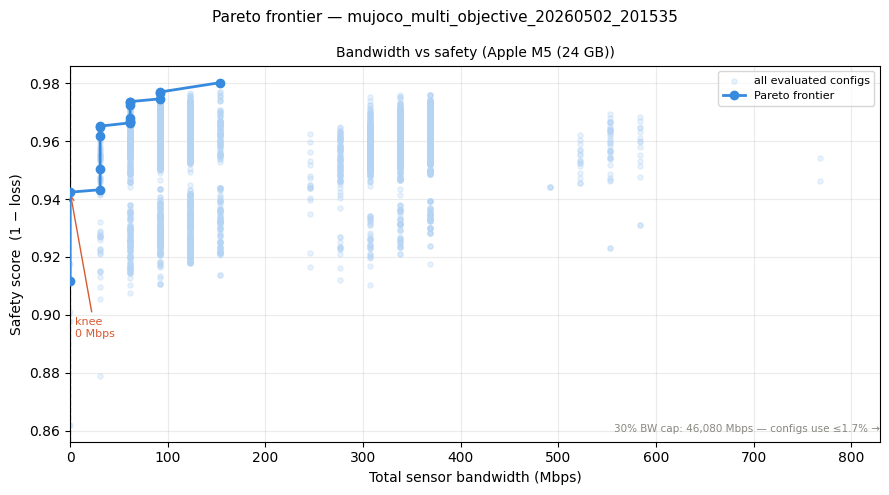

✅ plot_02_hardware_trends.png


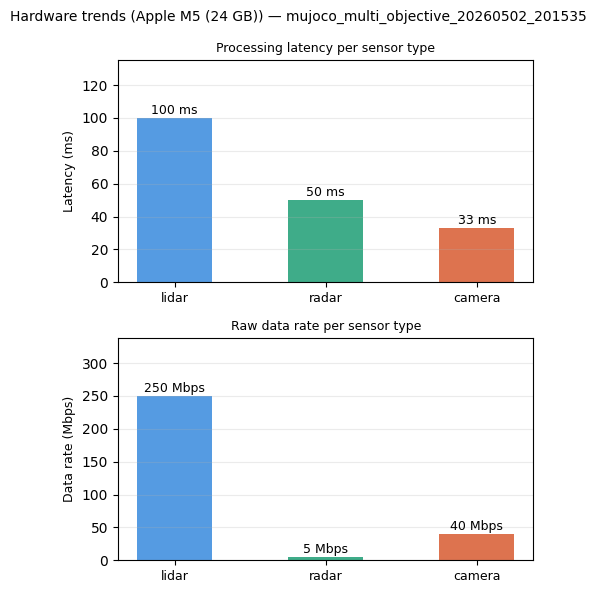

✅ plot_03_coverage_heatmap.png


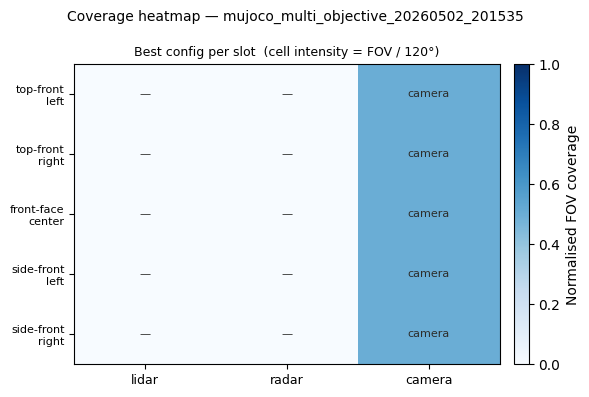

✅ plot_04_cma_diagnostic.png


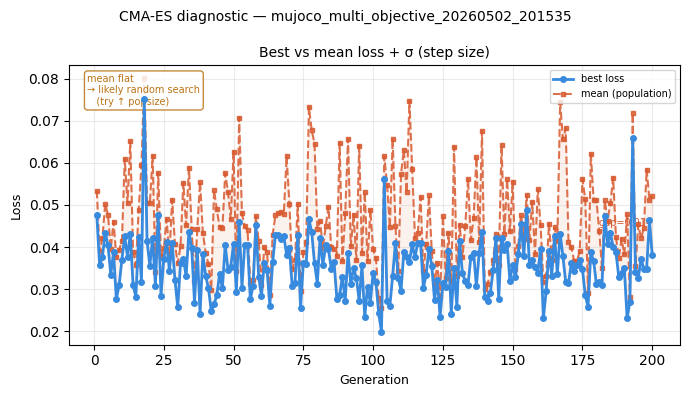

✅ plot_05_convergence_detail.png


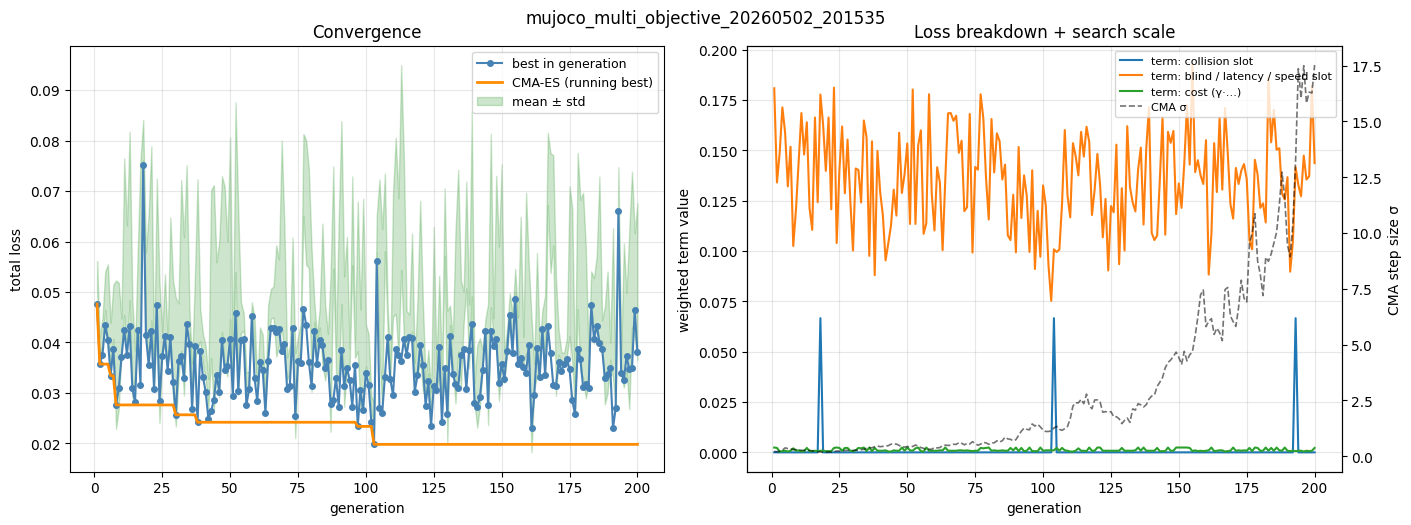


────────────────────────────────────────────────────────────
Saved 5 plots to results/mujoco_multi_objective_20260502_201535/
  plot_01_pareto.png
  plot_02_hardware_trends.png
  plot_03_coverage_heatmap.png
  plot_04_cma_diagnostic.png
  plot_05_convergence_detail.png

  Pareto configs : 18 / 4000
  BW range       : 0 – 768 Mbps
  Safety range   : 0.862 – 0.980
  Cap headroom   : configs use ≤1.7% of the 30% BW cap


In [ ]:
# ── Cell 11 ─ Visualisation dashboard (individual figures) ───────────────────
# Produces four separate saved images + inline display:
#   plot_01_pareto.png           — Pareto frontier: bandwidth vs safety
#   plot_02_hardware_trends.png  — Latency + data-rate bars per sensor type
#   plot_03_coverage_heatmap.png — FOV-weighted slot assignment heatmap
#   plot_04_cma_diagnostic.png   — CMA-ES best/mean loss + σ convergence

import json, os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

TARGET = Path("/content/sensor_placement_opt_MUJOCO_ver")
os.chdir(TARGET)
if str(TARGET) not in sys.path:
    sys.path.insert(0, str(TARGET))

from sensor_opt.config.specs import prepare_experiment_config

# ── Locate most-recent run ────────────────────────────────────────────────────
results = sorted(Path("results").glob("mujoco_*"), key=lambda p: p.name, reverse=True)
assert results, "No results dir — run Cell 9 first."
run_dir = results[0]
print(f"Run: {run_dir.name}")

# ── Load experiment config ────────────────────────────────────────────────────
with open(run_dir / "config.json", encoding="utf-8") as f:
    full_cfg = prepare_experiment_config(json.load(f))
mounts = list(full_cfg["mounting_slots"])

# ── Load evaluated pool ───────────────────────────────────────────────────────
with open(run_dir / "evaluated_pool.json", encoding="utf-8") as f:
    pool = json.load(f)
print(f"Pool: {len(pool)} evaluated configs")

# ── Recover best sensor configuration ────────────────────────────────────────
checkpoints = sorted(
    (run_dir / "checkpoints").glob("checkpoint_gen*.json"),
    key=lambda p: p.name,
)
if checkpoints:
    with open(checkpoints[-1], encoding="utf-8") as f:
        bcfg = json.load(f).get("best_config")
    print(f"Best config: {checkpoints[-1].name}")
else:
    _W = LOSS_WEIGHT_OVERRIDES
    def _scalar_loss(obj):
        return (
            _W["w_acc"]  * obj.get("L_detection_rate",      0.0)
          + _W["w_lat"]  * obj.get("L_first_detection_time", 0.0)
          + _W["w_cost"] * obj.get("L_hardware",             0.0)
        )
    losses   = [_scalar_loss(r.get("objectives", {})) for r in pool]
    best_idx = int(np.argmin(losses))
    bcfg     = pool[best_idx].get("config")
    print(f"Best config: pool idx={best_idx}, loss={losses[best_idx]:.4f}")

# ── Per-slot sensor assignments ───────────────────────────────────────────────
SLOT_LABELS = {
    "top_front_edge_l":  "top-front\nleft",
    "top_front_edge_r":  "top-front\nright",
    "front_face_center": "front-face\ncenter",
    "side_front_edge_l": "side-front\nleft",
    "side_front_edge_r": "side-front\nright",
}
slot_sensor = {s: "disabled" for s in SLOT_LABELS}
if bcfg and "sensors" in bcfg:
    for s in bcfg["sensors"]:
        slot  = s.get("slot")
        stype = s.get("type", "disabled")
        if slot in slot_sensor:
            slot_sensor[slot] = stype

print("\nBest config per slot:")
for slot, stype in slot_sensor.items():
    print(f"  {slot:24s}  →  {stype}")

# ── Helpers ───────────────────────────────────────────────────────────────────
_W        = LOSS_WEIGHT_OVERRIDES
_BW_MBPS  = HARDWARE_PLATFORM["memory_bandwidth_gbps"] * 1_000
_CAP_MBPS = MAX_BANDWIDTH_FRACTION * _BW_MBPS

def scalar_loss(obj: dict) -> float:
    return (
        _W["w_acc"]  * obj.get("L_detection_rate",      0.0)
      + _W["w_lat"]  * obj.get("L_first_detection_time", 0.0)
      + _W["w_cost"] * obj.get("L_hardware",             0.0)
    )

def cost_units_to_mbps(cu: float) -> float:
    return (cu / 10_000.0) * _BW_MBPS

def pareto_frontier_indices(bw: np.ndarray, saf: np.ndarray) -> np.ndarray:
    order           = np.argsort(bw)
    front_idx       = []
    running_max_saf = -np.inf
    for i in order:
        if saf[i] > running_max_saf:
            front_idx.append(i)
            running_max_saf = saf[i]
    return np.array(front_idx, dtype=int)

# ── Pareto data ───────────────────────────────────────────────────────────────
bw_vals, saf_vals = [], []
for r in pool:
    obj    = r.get("objectives", {})
    cost_u = obj.get("cost_usd")
    if cost_u is None:
        continue
    bw_vals.append(cost_units_to_mbps(cost_u))
    saf_vals.append(1.0 - scalar_loss(obj))

bw_arr  = np.array(bw_vals)
saf_arr = np.array(saf_vals)

front_idx    = pareto_frontier_indices(bw_arr, saf_arr)
fbw          = bw_arr[front_idx]
fsaf         = saf_arr[front_idx]
frontier_sum = len(front_idx)
cap_pct      = bw_arr.max() / _CAP_MBPS * 100

# ── generations.csv ───────────────────────────────────────────────────────────
gen_csv = run_dir / "generations.csv"
assert gen_csv.is_file(), "generations.csv not found — run Cell 9 first."
df  = pd.read_csv(gen_csv)
col = {c.lower().strip(): c for c in df.columns}

def _col(*candidates):
    for c in candidates:
        if c in col:
            return col[c]
    return None

gen_col   = _col("generation", "gen", "epoch")
best_col  = _col("best_loss",  "best", "min_loss")
mean_col  = _col("mean_loss",  "mean", "avg_loss", "average_loss", "pop_mean")
sigma_col = _col("sigma",      "σ",    "std",      "step_size")
assert gen_col and best_col, f"Need generation + best_loss columns. Got: {df.columns.tolist()}"

gens  = df[gen_col].values
best  = df[best_col].values
mean  = df[mean_col].values  if mean_col  else None
sigma = df[sigma_col].values if sigma_col else None

# ── Shared style ──────────────────────────────────────────────────────────────
COLORS       = {"lidar": "#378ADD", "radar": "#1D9E75", "camera": "#D85A30", "disabled": "#B4B2A9"}
SENSOR_ORDER = ["lidar", "radar", "camera"]
FOV_MAX      = 120.0
FOV_WEIGHT   = {s: SENSOR_SPECS[s]["fov_deg"] / FOV_MAX for s in SENSOR_SPECS}
SAVE_KW      = dict(dpi=150, bbox_inches="tight")

saved = []   # collect paths for the final summary


# ══════════════════════════════════════════════════════════════════════════════
# ① Pareto frontier — bandwidth (Mbps) vs safety
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(9, 5))
fig1.suptitle(f"Pareto frontier — {run_dir.name}", fontsize=11)

ax.scatter(bw_arr, saf_arr, s=14, alpha=0.30, color="#B5D4F4",
           label="all evaluated configs", zorder=2)
ax.plot(fbw, fsaf, "o-", color="#378ADD", linewidth=2.0, markersize=6,
        label="Pareto frontier", zorder=4)

if len(fbw) > 2:
    gains  = np.diff(fsaf) / (np.diff(fbw) + 1e-9)
    knee_i = int(np.argmax(gains)) + 1
    ax.axvline(fbw[knee_i], color="#D85A30", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(
        f"knee\n{fbw[knee_i]:.0f} Mbps",
        xy=(fbw[knee_i], fsaf[knee_i]),
        xytext=(fbw[knee_i] + 0.03 * np.ptp(fbw), fsaf[knee_i] - 0.05),
        fontsize=8, color="#D85A30",
        arrowprops=dict(arrowstyle="->", color="#D85A30", lw=1),
    )

ax.annotate(
    f"30% BW cap: {_CAP_MBPS:,.0f} Mbps — configs use ≤{cap_pct:.1f}% →",
    xy=(1.0, 0.02), xycoords="axes fraction",
    fontsize=7.5, color="#888780", ha="right", va="bottom",
)
bw_lo = max(0.0, bw_arr.min() - 0.08 * np.ptp(bw_arr))
bw_hi = bw_arr.max() + 0.08 * np.ptp(bw_arr)
ax.set_xlim(bw_lo, bw_hi)
ax.set_xlabel("Total sensor bandwidth (Mbps)", fontsize=10)
ax.set_ylabel("Safety score  (1 − loss)", fontsize=10)
ax.set_title(f"Bandwidth vs safety ({HARDWARE_PLATFORM['name']})", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig1.tight_layout()

p = run_dir / "plot_01_pareto.png"
fig1.savefig(p, **SAVE_KW)
saved.append(p)
print(f"✅ {p.name}")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# ② Hardware trends — latency + data-rate bars
# ══════════════════════════════════════════════════════════════════════════════
fig2, (ax_lat, ax_dr) = plt.subplots(2, 1, figsize=(5, 6))
fig2.suptitle(f"Hardware trends ({HARDWARE_PLATFORM['name']}) — {run_dir.name}", fontsize=10)

bar_colors = [COLORS[s] for s in SENSOR_ORDER]
x          = np.arange(len(SENSOR_ORDER))

latencies = [SENSOR_SPECS[s]["latency_s"] * 1_000 for s in SENSOR_ORDER]
b_lat = ax_lat.bar(x, latencies, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(b_lat, latencies):
    ax_lat.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.0f} ms", ha="center", va="bottom", fontsize=9)
ax_lat.set_xticks(x)
ax_lat.set_xticklabels(SENSOR_ORDER, fontsize=9)
ax_lat.set_ylabel("Latency (ms)", fontsize=9)
ax_lat.set_title("Processing latency per sensor type", fontsize=9)
ax_lat.set_ylim(0, max(latencies) * 1.35)
ax_lat.grid(axis="y", alpha=0.25)

data_rates = [SENSOR_SPECS[s]["data_rate_mbps"] for s in SENSOR_ORDER]
b_dr = ax_dr.bar(x, data_rates, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(b_dr, data_rates):
    ax_dr.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
               f"{val} Mbps", ha="center", va="bottom", fontsize=9)
ax_dr.set_xticks(x)
ax_dr.set_xticklabels(SENSOR_ORDER, fontsize=9)
ax_dr.set_ylabel("Data rate (Mbps)", fontsize=9)
ax_dr.set_title("Raw data rate per sensor type", fontsize=9)
ax_dr.set_ylim(0, max(data_rates) * 1.35)
ax_dr.grid(axis="y", alpha=0.25)

fig2.tight_layout()
p = run_dir / "plot_02_hardware_trends.png"
fig2.savefig(p, **SAVE_KW)
saved.append(p)
print(f"✅ {p.name}")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# ③ Coverage heatmap — FOV-weighted slot assignment
# ══════════════════════════════════════════════════════════════════════════════
slots   = list(SLOT_LABELS.keys())
n_slots = len(slots)
mat = np.zeros((n_slots, len(SENSOR_ORDER)))
for i, slot in enumerate(slots):
    assigned = slot_sensor.get(slot, "disabled")
    for j, stype in enumerate(SENSOR_ORDER):
        if assigned == stype:
            mat[i, j] = FOV_WEIGHT[stype]

fig3, ax = plt.subplots(figsize=(6, 4))
fig3.suptitle(f"Coverage heatmap — {run_dir.name}", fontsize=10)

im = ax.imshow(mat, aspect="auto", cmap="Blues", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_xticks(range(len(SENSOR_ORDER)))
ax.set_xticklabels(SENSOR_ORDER, fontsize=9)
ax.set_yticks(range(n_slots))
ax.set_yticklabels(list(SLOT_LABELS.values()), fontsize=8)
ax.set_title("Best config per slot  (cell intensity = FOV / 120°)", fontsize=9)
plt.colorbar(im, ax=ax, label="Normalised FOV coverage", fraction=0.04, pad=0.03)

for i in range(n_slots):
    for j, stype in enumerate(SENSOR_ORDER):
        v   = mat[i, j]
        txt = stype if v > 0 else "—"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=8, color="white" if v > 0.5 else "#2C2C2A")

fig3.tight_layout()
p = run_dir / "plot_03_coverage_heatmap.png"
fig3.savefig(p, **SAVE_KW)
saved.append(p)
print(f"✅ {p.name}")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# ④ CMA-ES diagnostic — best / mean loss + σ
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax_cma = plt.subplots(figsize=(7, 4))
fig4.suptitle(f"CMA-ES diagnostic — {run_dir.name}", fontsize=10)

ax_cma_r = ax_cma.twinx() if sigma is not None else None

ax_cma.plot(gens, best, "o-", color="#378ADD", linewidth=2, markersize=4,
            label="best loss", zorder=4)

if mean is not None:
    ax_cma.plot(gens, mean, "s--", color="#D85A30", linewidth=1.5, markersize=3,
                alpha=0.85, label="mean (population)", zorder=3)
    ax_cma.fill_between(gens, best, mean, alpha=0.08, color="#D85A30")
    gap = mean[-1] - best[-1]
    ax_cma.annotate(f"gap={gap:.3f}",
                    xy=(gens[-1], (mean[-1] + best[-1]) / 2),
                    fontsize=7, color="#D85A30", ha="right")
else:
    ax_cma.text(0.5, 0.5, "mean_loss not found\nin generations.csv",
                transform=ax_cma.transAxes, ha="center", va="center",
                fontsize=8, color="#888780",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

if sigma is not None and ax_cma_r is not None:
    ax_cma_r.plot(gens, sigma, "^:", color="#1D9E75", linewidth=1.2, markersize=3,
                  alpha=0.75, label="σ (step size)")
    ax_cma_r.set_ylabel("σ (step size)", fontsize=8, color="#1D9E75")
    ax_cma_r.tick_params(axis="y", labelcolor="#1D9E75", labelsize=7)
    ax_cma_r.legend(fontsize=7, loc="upper right")

if mean is not None and len(mean) > 3:
    slope = np.polyfit(gens, mean, 1)[0]
    if slope < -0.001:
        verdict, vcolor = "mean trending ↓\n→ CMA-ES learning",                "#0F6E56"
    elif slope > 0.001:
        verdict, vcolor = "mean trending ↑\n→ diverging",                      "#A32D2D"
    else:
        verdict, vcolor = "mean flat\n→ likely random search\n   (try ↑ popsize)", "#BA7517"
    ax_cma.text(0.03, 0.97, verdict, transform=ax_cma.transAxes,
                fontsize=7, va="top", color=vcolor,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          alpha=0.85, edgecolor=vcolor))

ax_cma.set_xlabel("Generation", fontsize=9)
ax_cma.set_ylabel("Loss", fontsize=9)
ax_cma.set_title("Best vs mean loss + σ (step size)", fontsize=10)
ax_cma.legend(fontsize=7, loc="upper right" if sigma is None else "center right")
ax_cma.grid(True, alpha=0.25)
fig4.tight_layout()

p = run_dir / "plot_04_cma_diagnostic.png"
fig4.savefig(p, **SAVE_KW)
saved.append(p)
print(f"✅ {p.name}")
plt.show()


# ── ⑤ Library convergence detail (optional) ───────────────────────────────────
try:
    from sensor_opt.plotting.cma_matplotlib import plot_cma_generations_matplotlib

    fig5 = plot_cma_generations_matplotlib(gen_csv, title=run_dir.name)
    p    = run_dir / "plot_05_convergence_detail.png"
    fig5.savefig(p, **SAVE_KW)
    saved.append(p)
    print(f"✅ {p.name}")
    plt.show()
except Exception as e:
    print(f"⚠️  plot_cma_generations_matplotlib skipped: {e}")


# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print(f"Saved {len(saved)} plots to {run_dir}/")
for p in saved:
    print(f"  {p.name}")
print(f"\n  Pareto configs : {frontier_sum} / {len(pool)}")
print(f"  BW range       : {bw_arr.min():.0f} – {bw_arr.max():.0f} Mbps")
print(f"  Safety range   : {saf_arr.min():.3f} – {saf_arr.max():.3f}")
print(f"  Cap headroom   : configs use ≤{cap_pct:.1f}% of the {int(MAX_BANDWIDTH_FRACTION*100)}% BW cap")